**Método de Otsu (Limiarização Global Automática)**

**Como funciona**: Ele analisa o histograma da imagem inteira de uma só vez e calcula matematicamente um único "ponto de corte" (limiar) ideal para separar os objetos (folhas) do fundo (terra).

**O problema na lavoura**: Como ele aplica uma regra única para a foto toda, ele falha em condições de iluminação irregular. Se uma folha estiver sob uma sombra muito escura, seus pixels terão valores parecidos com os da terra escura. O método de Otsu cortará os dois juntos, "cegando" o sistema para as plantas que estão na sombra.

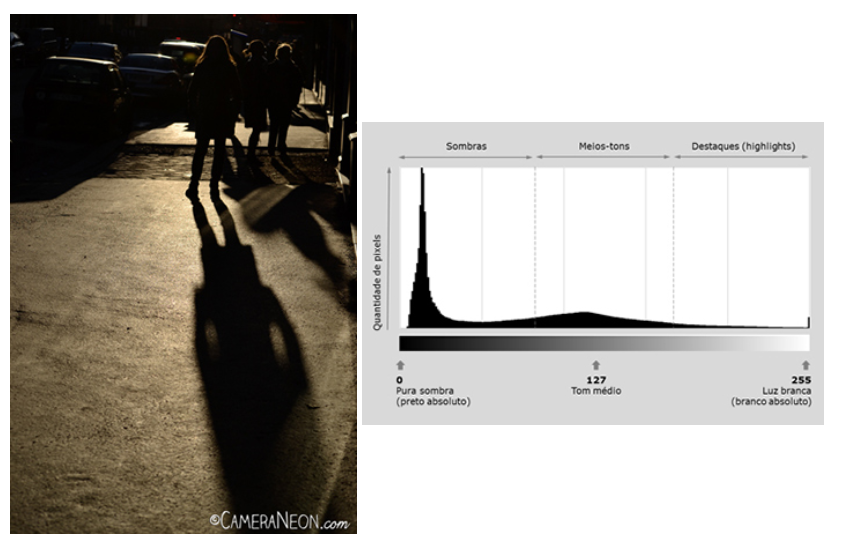

**Limiarização Adaptativa (A Solução para Sombras)**

**Como funciona**: Em vez de olhar para o cenário macro, o algoritmo divide a imagem em pequenas regiões (blocos de pixels). Ele então calcula um ponto de corte dinâmico e exclusivo para cada uma dessas micro-regiões, baseando-se na média de brilho local.

**A vantagem na lavoura**: Ela se adapta à luz. Se um bloco da imagem está sob o sol forte, a "régua" de corte sobe. Se o bloco vizinho está sob uma sombra severa, a "régua" desce. Isso permite que a máquina extraia os contornos exatos das folhas saudáveis ou doentes mesmo que elas estejam escondidas na escuridão da sombra, resolvendo o problema central da AgriTech.

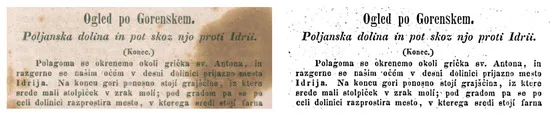

In [28]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow


1. Preparação do Terreno (Carregamento e Limpeza)
A primeira coisa que fiz foi carregar a imagem e aplicar um desfoque suave (o Gaussian Blur). Como imagens de drones têm uma resolução muito alta, a textura da terra e as imperfeições das folhas geram um "ruído" visual para o algoritmo. Esse filtro dá uma limpada na imagem para que o sistema foque nas grandes massas de cor, ignorando grãos de areia ou pedrinhas.

In [29]:
# Carrego a imagem original capturada pelo drone
img = cv2.imread('soja.jpeg')
print("Largura em pixels: ")
print(img.shape[1])  # largura da imagem
print("Altura em pixels: ")
print(img.shape[0])  # altura da imagem
print("Qtde de canais: ")
print(img.shape[2])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Aplico o filtro para reduzir os ruídos e texturas desnecessárias
img_blur = cv2.GaussianBlur(img_rgb, (5, 5), 0)

Largura em pixels: 
640
Altura em pixels: 
360
Qtde de canais: 
3


2. Abandono do RGB pelo HSV
Esse foi o principal requisito do projeto. Se eu mantivesse o código trabalhando em RGB (Vermelho, Verde e Azul), ele ia falhar nas áreas de sombra, porque uma sombra altera todos os três canais de cor ao mesmo tempo.

A minha solução foi converter a imagem para o espaço HSV (Matiz, Saturação e Brilho). Dessa forma, a "cor pura" da folha fica isolada no canal Matiz (Hue). Uma folha verde sob luz solar intensa e uma folha verde no escuro continuam sendo lidas pelo meu código com o mesmo valor de Matiz.

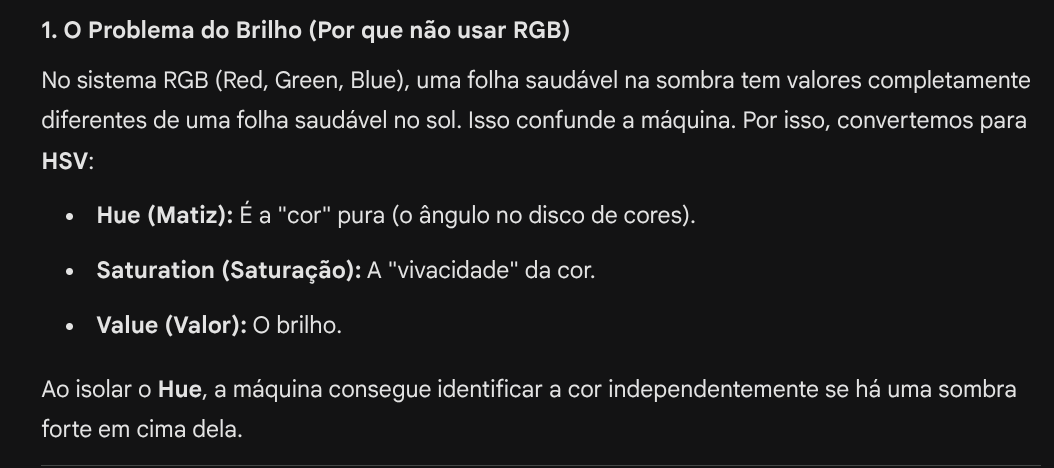

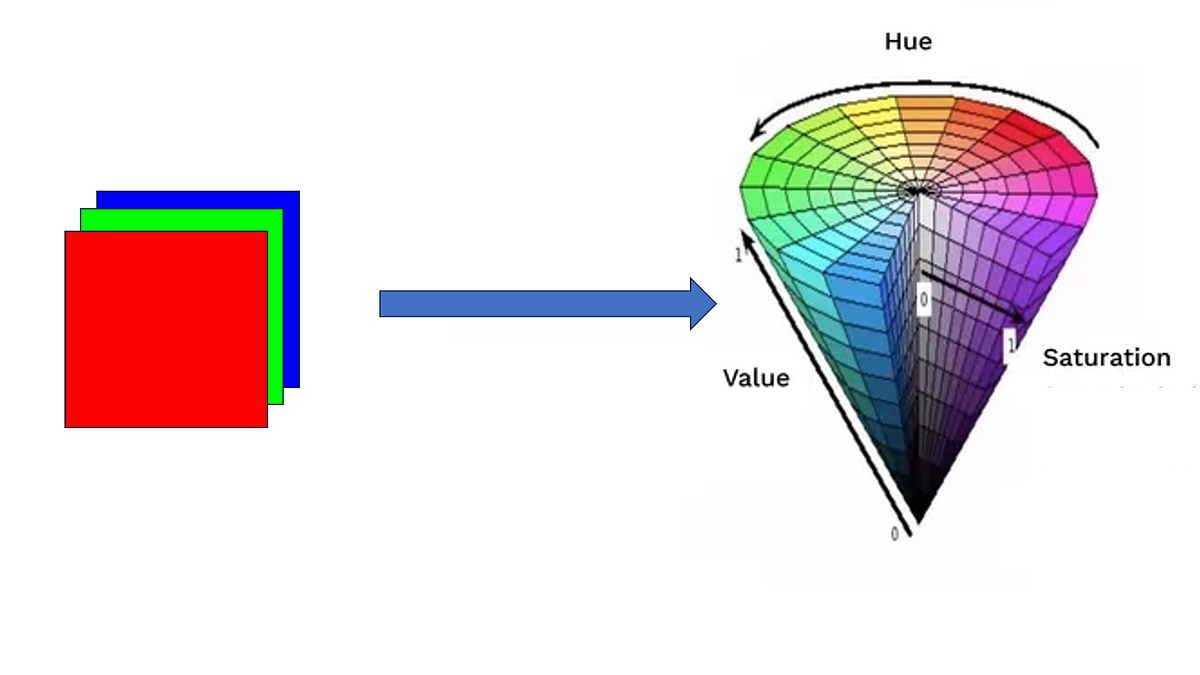

In [30]:
# Abandono o espaço RGB para não ser enganado pelas sombras
hsv = cv2.cvtColor(img_blur, cv2.COLOR_RGB2HSV)

3. Criando as Máscaras:
Com o HSV em mãos, comecei a separar o que é planta do que é terra (fundo). Calibrei os limites numéricos para identificar exatamente o que consideramos saudável (verde) e doente (amarelado). A função cv2.inRange recorta exatamente o que está nesses intervalos, criando máscaras onde a planta fica branca e a terra fica preta.

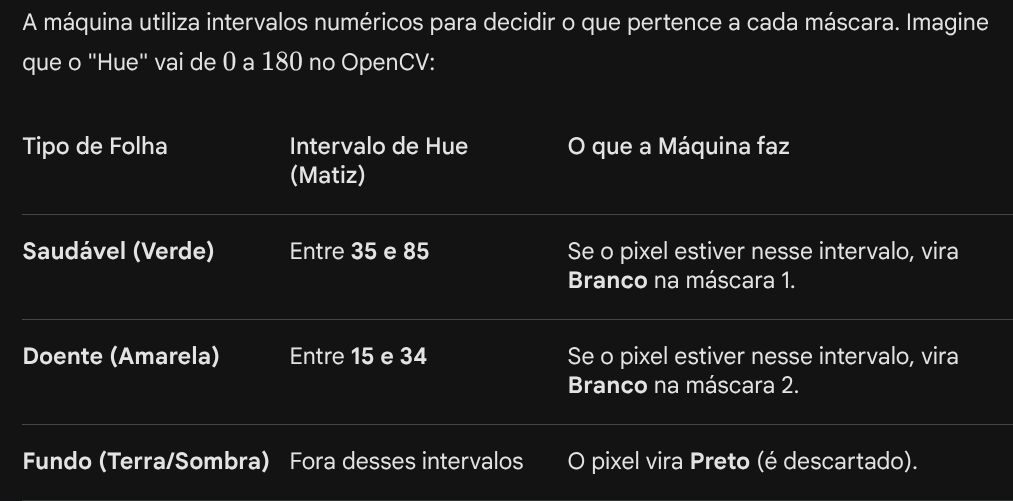

In [31]:
# Defino a "assinatura" da planta saudável
verde_baixo = np.array([35, 40, 40])
verde_alto = np.array([85, 255, 255])
mask_verde = cv2.inRange(hsv, verde_baixo, verde_alto)

# Defino a "assinatura" da planta doente/amarelada
amarelo_baixo = np.array([15, 100, 100])
amarelo_alto = np.array([34, 255, 255])
mask_amarelo = cv2.inRange(hsv, amarelo_baixo, amarelo_alto)

4. A Batalha Contra as Sombras (Limiarização Adaptativa)
O enunciado dizia que algoritmos de threshold global quebravam. Um threshold global tenta usar um valor único de corte para a foto toda. Se metade da foto está nublada, o algoritmo se perde.

Para resolver isso, implementei a Limiarização Adaptativa. Ao invés de usar uma regra única para a foto toda, meu código analisa pequenos blocos de vizinhança (de 11 em 11 pixels). Se um bloco específico da plantação estiver na sombra, o algoritmo "abaixa a régua" localmente para conseguir enxergar as folhas que estão ali no escuro.

In [32]:

# Crio uma versão em tons de cinza para análise de contraste
gray = cv2.cvtColor(img_blur, cv2.COLOR_RGB2GRAY)

# Aplico a técnica adaptativa para lidar com iluminação irregular
thresh_adaptativo = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 11, 2
)

5. Apresentação dos Resultados (O Painel Visual)
Para provar que o algoritmo funciona, eu monto um painel visual. Coloco a imagem original e as três máscaras que criei lado a lado. Isso permite que a equipe da AgriTech bata o olho e veja exatamente o que a máquina está identificando em cada etapa.

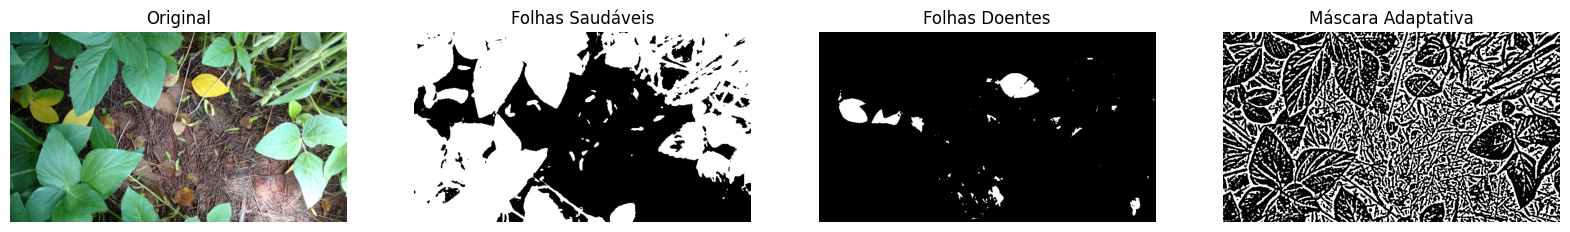

In [33]:
# Preparo os títulos e as imagens para exibição
titulos = ['Original', 'Folhas Saudáveis', 'Folhas Doentes', 'Máscara Adaptativa']
imagens = [img_rgb, mask_verde, mask_amarelo, thresh_adaptativo]

# Ploto as 4 imagens em linha
plt.figure(figsize=(20, 10))
for i in range(4):
    plt.subplot(1, 4, i+1)
    # Uso mapa de cores cinza apenas para as máscaras
    plt.imshow(imagens[i], cmap='gray' if i > 0 else None)
    plt.title(titulos[i])
    plt.axis('off')

plt.show()

6. O Diagnóstico Final (Métricas de Negócio)
Por fim, eu transformo essas imagens em dados acionáveis. Conto os pixels brancos das máscaras de cor. Somando a área amarela e dividindo pelo total da planta, entrego o percentual exato de infestação da lavoura para a tomada de decisão.

In [34]:
# Conto os pixels que passaram nos meus filtros
total_verde = np.sum(mask_verde > 0)
total_amarelo = np.sum(mask_amarelo > 0)
total_plantas = total_verde + total_amarelo

# Calculo a gravidade do problema na lavoura
if total_plantas > 0:
    porcentagem_doente = (total_amarelo / total_plantas) * 100
else:
    porcentagem_doente = 0

print(f"--- RELATÓRIO DO DRONE ---")
print(f"Área Saudável: {total_verde} px")
print(f"Área Doente: {total_amarelo} px")
print(f"Infestação: {porcentagem_doente:.2f}%")

--- RELATÓRIO DO DRONE ---
Área Saudável: 123970 px
Área Doente: 7419 px
Infestação: 5.65%
